### ***Initial Checking***

In [32]:
from google.colab import drive
drive.mount("/content/drive")

import os
import sys
import glob

PROJECT_ROOT = "/content/drive/MyDrive/Generalizable-DDA-RL"

os.chdir(PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("Project root:", os.getcwd())
print("\nAvailable models:")

for file in glob.glob("models/*"):
    print(file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/Generalizable-DDA-RL

Available models:
models/ppo_dda.zip


In [33]:
import inspect

from src.environment import GADDAEnv

print("GADDAEnv constructor:\n")
print(inspect.signature(GADDAEnv))

print("\n\n__init__ signature:\n")
print(inspect.signature(GADDAEnv.__init__))

GADDAEnv constructor:

(max_steps=200, target_win_rate=0.7, player_config=None, seed=None)


__init__ signature:

(self, max_steps=200, target_win_rate=0.7, player_config=None, seed=None)


In [34]:
import inspect

print(inspect.getsource(GADDAEnv.__init__))

    def __init__(
        self,
        max_steps=200,
        target_win_rate=0.70,
        player_config=None,
        seed=None
    ):

        super().__init__()

        if player_config is None:
            player_config = {
                "initial_skill": 0.5,
                "learning_rate": 0.0,
                "fatigue_rate": 0.0,
                "noise_std": 0.05
            }

        self.max_steps = max_steps
        self.target_win_rate = target_win_rate
        self.player_config = player_config
        self.seed_value = seed

        self.action_space = spaces.Box(
            low=0.0,
            high=1.0,
            shape=(1,),
            dtype=np.float32
        )

        self.observation_space = spaces.Box(
            low=0.0,
            high=1.0,
            shape=(5,),
            dtype=np.float32
        )

        self.player = None

        self.step_count = 0
        self.difficulty = 0.5

        self.outcome_history = []
        self.difficulty_histor

### ***Project Setup***

In [35]:
from google.colab import drive
drive.mount("/content/drive")

import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = "/content/drive/MyDrive/Generalizable-DDA-RL"

os.chdir(PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

os.makedirs("results/generalization", exist_ok=True)
os.makedirs("results/generalization/figures", exist_ok=True)
os.makedirs("results/generalization/trajectories", exist_ok=True)
os.makedirs("results/generalization/tables", exist_ok=True)

print("Project root:", os.getcwd())

print("\nModels found:")
for file in glob.glob("models/*"):
    print(file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/Generalizable-DDA-RL

Models found:
models/ppo_dda.zip


In [36]:
%pip install stable_baselines3
from stable_baselines3 import PPO

MODEL_PATH = "models/ppo_dda.zip"

model = PPO.load(
    MODEL_PATH,
    device="cpu"
)

print("\n\nPPO model loaded successfully!")
print("Model path:", MODEL_PATH)

print("\nObservation space:")
print(model.observation_space)

print("\nAction space:")
print(model.action_space)



PPO model loaded successfully!
Model path: models/ppo_dda.zip

Observation space:
Box(0.0, 1.0, (5,), float32)

Action space:
Box(0.0, 1.0, (1,), float32)


### ***Define Unseen Player Profiles***

In [37]:
UNSEEN_PLAYER_PROFILES = {

    "Unseen Low Skill": {
        "initial_skill": 0.15,
        "learning_rate": 0.0,
        "fatigue_rate": 0.0,
        "noise_std": 0.05
    },

    "Unseen High Skill": {
        "initial_skill": 0.90,
        "learning_rate": 0.0,
        "fatigue_rate": 0.0,
        "noise_std": 0.05
    },

    "Unseen Fast Learning": {
        "initial_skill": 0.20,
        "learning_rate": 0.006,
        "fatigue_rate": 0.0,
        "noise_std": 0.05
    },

    "Unseen Strong Fatigue": {
        "initial_skill": 0.90,
        "learning_rate": 0.0,
        "fatigue_rate": 0.005,
        "noise_std": 0.05
    },

    "Unseen High Noise": {
        "initial_skill": 0.30,
        "learning_rate": 0.0,
        "fatigue_rate": 0.0,
        "noise_std": 0.20
    }
}

for name, config in UNSEEN_PLAYER_PROFILES.items():
    print(name)
    print(config)
    print("-" * 50)

Unseen Low Skill
{'initial_skill': 0.15, 'learning_rate': 0.0, 'fatigue_rate': 0.0, 'noise_std': 0.05}
--------------------------------------------------
Unseen High Skill
{'initial_skill': 0.9, 'learning_rate': 0.0, 'fatigue_rate': 0.0, 'noise_std': 0.05}
--------------------------------------------------
Unseen Fast Learning
{'initial_skill': 0.2, 'learning_rate': 0.006, 'fatigue_rate': 0.0, 'noise_std': 0.05}
--------------------------------------------------
Unseen Strong Fatigue
{'initial_skill': 0.9, 'learning_rate': 0.0, 'fatigue_rate': 0.005, 'noise_std': 0.05}
--------------------------------------------------
Unseen High Noise
{'initial_skill': 0.3, 'learning_rate': 0.0, 'fatigue_rate': 0.0, 'noise_std': 0.2}
--------------------------------------------------


### ***Generalisation Integrity Check***

In [38]:
generalization_profiles_df = pd.DataFrame.from_dict(
    UNSEEN_PLAYER_PROFILES,
    orient="index"
)

generalization_profiles_df.index.name = "Player Profile"

display(generalization_profiles_df)

generalization_profiles_df.to_csv(
    "results/generalization/tables/unseen_player_profiles.csv"
)

print("\nUnseen Player Profiles Saved :)\n")

,initial_skill,learning_rate,fatigue_rate,noise_std
Player Profile,,,,
Unseen Low Skill,0.15,0,0,0.05
Unseen High Skill,0.9,0,0,0.05
Unseen Fast Learning,0.2,0.006,0,0.05
Unseen Strong Fatigue,0.9,0,0.005,0.05
Unseen High Noise,0.3,0,0,0.2



Unseen Player Profiles Saved :)



/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### *Import Environment and Define Evaluation Constants*

In [39]:
from src.environment import GADDAEnv

TARGET_WIN_RATE = 0.70
MAX_STEPS = 200

GENERALIZATION_SEEDS = list(range(100, 110))

print("Target win rate:", TARGET_WIN_RATE)
print("Episode length:", MAX_STEPS)
print("Number of seeds:", len(GENERALIZATION_SEEDS))
print("Unseen profiles:", len(UNSEEN_PLAYER_PROFILES))

Target win rate: 0.7
Episode length: 200
Number of seeds: 10
Unseen profiles: 5


### ***PPO Evaluation Function***
This Function evaluates the Frozen Trained PPO Model

In [40]:
def evaluate_ppo_generalization(
    model,
    player_config,
    seed,
    deterministic=True
):

    env = GADDAEnv(
        max_steps=MAX_STEPS,
        target_win_rate=TARGET_WIN_RATE,
        player_config=player_config,
        seed=seed
    )

    obs, info = env.reset(seed=seed)

    terminated = False
    truncated = False

    total_reward = 0.0

    trajectory = []

    while not (terminated or truncated):

        action, _ = model.predict(
            obs,
            deterministic=deterministic
        )

        obs, reward, terminated, truncated, info = env.step(
            action
        )

        total_reward += reward

        trajectory.append({
            "Step": env.step_count,
            "Difficulty": float(
                np.asarray(action).flatten()[0]
            ),
            "Estimated Skill": env.estimated_skill,
            "Uncertainty": env.uncertainty,
            "Recent Win Rate": info.get(
                "recent_win_rate",
                np.nan
            ),
            "Error Rate": info.get(
                "error_rate",
                np.nan
            ),
            "Reward": reward
        })

    trajectory_df = pd.DataFrame(trajectory)

    return trajectory_df, total_reward

### ***Test PPO on one unseen player***

In [41]:
test_profile_name = "Unseen Low Skill"

test_profile = UNSEEN_PLAYER_PROFILES[
    test_profile_name
]

trajectory_df, total_reward = (
    evaluate_ppo_generalization(
        model=model,
        player_config=test_profile,
        seed=100
    )
)

print("Profile:", test_profile_name)
print("Total Reward:", round(total_reward, 4))

display(trajectory_df.head())

print("\nTrajectory length:", len(trajectory_df))

Profile: Unseen Low Skill
Total Reward: 158.5326


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Step,Difficulty,Estimated Skill,Uncertainty,Recent Win Rate,Error Rate,Reward
0,1,0,0.15951368,0.5,0,0.36575496,-3.0015755
1,2,0,0.20353662,0.5,0.5,0.17,0.622
2,3,0,0.18587406,0.5,0.33333333,0.20213826,-0.13356938
3,4,0,0.16539095,0.5,0.25,0.0548,-0.66072
4,5,0,0.18745071,0.3184815,0.4,0.01384,0.25449992



Trajectory length: 200


### ***Plot the First Unseen-Player Trajectory***

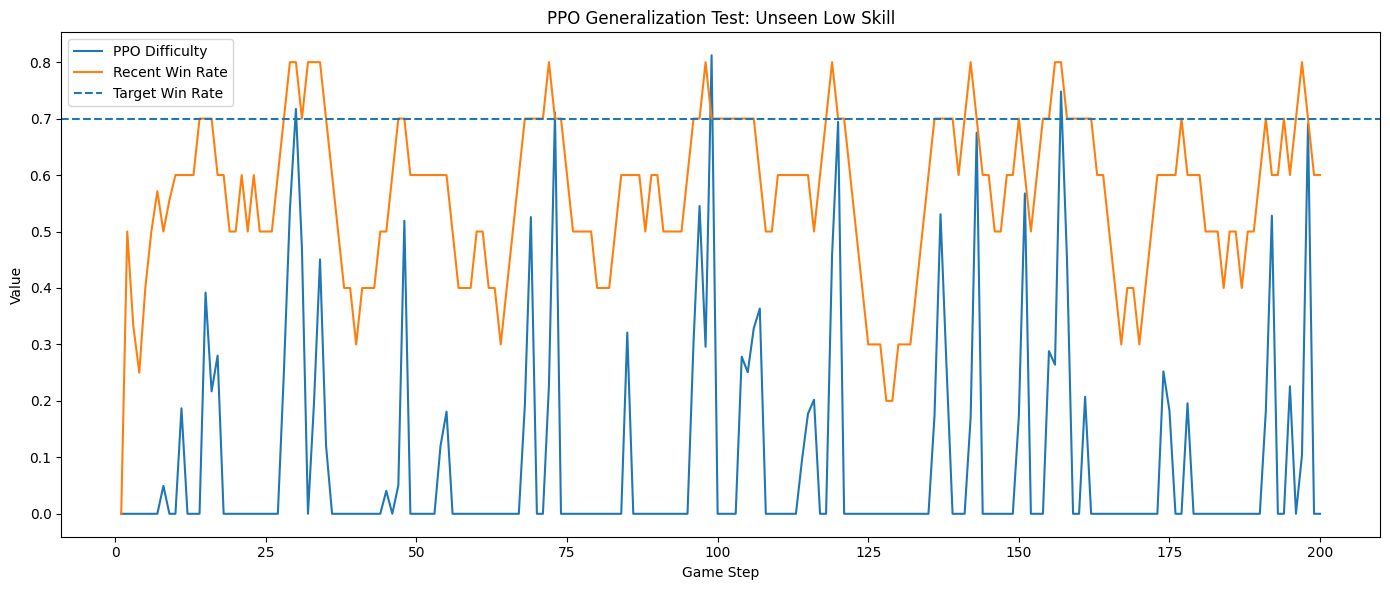

In [42]:
plt.figure(figsize=(14, 6))

plt.plot(
    trajectory_df["Step"],
    trajectory_df["Difficulty"],
    label="PPO Difficulty"
)

plt.plot(
    trajectory_df["Step"],
    trajectory_df["Recent Win Rate"],
    label="Recent Win Rate"
)

plt.axhline(
    TARGET_WIN_RATE,
    linestyle="--",
    label="Target Win Rate"
)

plt.xlabel("Game Step")
plt.ylabel("Value")

plt.title(
    f"PPO Generalization Test: {test_profile_name}"
)

plt.legend()

plt.tight_layout()

plt.show()

### ***Import and Create Baselines***

In [43]:
from src.baselines import (
    StaticPolicy,
    RuleBasedDDA
)

easy_policy = StaticPolicy(
    difficulty=0.30
)

medium_policy = StaticPolicy(
    difficulty=0.50
)

hard_policy = StaticPolicy(
    difficulty=0.70
)

rule_policy = RuleBasedDDA(
    target_win_rate=TARGET_WIN_RATE
)

print("Baselines Created Successfully!")

Baselines Created Successfully!


### ***Create one common evaluation function***
This is important because PPO and every baseline must be evaluated using the same environment and metrics

In [63]:
def evaluate_policy_generalization(
    policy,
    player_config,
    seed,
    method_name
):

    env = GADDAEnv(
        max_steps=MAX_STEPS,
        target_win_rate=TARGET_WIN_RATE,
        player_config=player_config,
        seed=seed
    )

    obs, info = env.reset(seed=seed)

    if hasattr(policy, "reset"):
        policy.reset()

    terminated = False
    truncated = False

    total_reward = 0.0

    trajectory = []

    while not (terminated or truncated):

        if method_name == "PPO DDA":

            action, _ = policy.predict(
                obs,
                deterministic=True
            )

        else:

            action = policy.select_action(
                obs
            )

        obs, reward, terminated, truncated, info = env.step(
            action
        )

        total_reward += reward

        trajectory.append({
            "Step": env.step_count,
            "Difficulty": float(
                np.asarray(action).flatten()[0]
            ),
            "Estimated Skill": float(
                env.estimated_skill
            ),
            "Uncertainty": float(
                env.uncertainty
            ),
            "Recent Win Rate": float(
                info.get(
                    "recent_win_rate",
                    np.nan
                )
            ),
            "Error Rate": float(
                info.get(
                    "error_rate",
                    np.nan
                )
            ),
            "Reward": float(reward)
        })

    trajectory_df = pd.DataFrame(
        trajectory
    )

    final_win_rate = (
        trajectory_df[
            "Recent Win Rate"
        ].iloc[-1]
    )

    mean_win_rate = (
        trajectory_df[
            "Recent Win Rate"
        ].mean()
    )

    win_rate_error = (
        abs(
            mean_win_rate
            -
            TARGET_WIN_RATE
        )
    )

    difficulty_std = (
        trajectory_df[
            "Difficulty"
        ].std()
    )

    mean_abs_difficulty_change = (
        trajectory_df[
            "Difficulty"
        ]
        .diff()
        .abs()
        .mean()
    )

    summary = {
        "Method": method_name,
        "Total Reward": total_reward,
        "Final Win Rate": final_win_rate,
        "Mean Rolling Win Rate": mean_win_rate,
        "Win Rate Error": win_rate_error,
        "Mean Difficulty": trajectory_df[
            "Difficulty"
        ].mean(),
        "Difficulty Std": difficulty_std,
        "Mean Absolute Difficulty Change":
            mean_abs_difficulty_change,
        "Episode Length": len(
            trajectory_df
        )
    }

    return trajectory_df, summary

### ***Sanity Test PPO and Rule-Based on One Unseen Player***

In [64]:
TEST_PROFILE_NAME = "Unseen Low Skill"

TEST_CONFIG = (
    UNSEEN_PLAYER_PROFILES[
        TEST_PROFILE_NAME
    ]
)

TEST_SEED = 100


ppo_trajectory, ppo_summary = (
    evaluate_policy_generalization(
        policy=model,
        player_config=TEST_CONFIG,
        seed=TEST_SEED,
        method_name="PPO DDA"
    )
)


rule_trajectory, rule_summary = (
    evaluate_policy_generalization(
        policy=rule_policy,
        player_config=TEST_CONFIG,
        seed=TEST_SEED,
        method_name="Rule-Based DDA"
    )
)


print("PPO:")
print(ppo_summary)

print("\nRule-Based:")
print(rule_summary)

PPO:
{'Method': 'PPO DDA', 'Total Reward': 158.53263944299385, 'Final Win Rate': np.float64(0.6), 'Mean Rolling Win Rate': np.float64(0.5650515873015872), 'Win Rate Error': np.float64(0.13494841269841273), 'Mean Difficulty': np.float64(0.09214131159707904), 'Difficulty Std': 0.1835459959751189, 'Mean Absolute Difficulty Change': np.float64(0.11206805713512191), 'Episode Length': 200}

Rule-Based:
{'Method': 'Rule-Based DDA', 'Total Reward': 150.20473165238164, 'Final Win Rate': np.float64(0.9), 'Mean Rolling Win Rate': np.float64(0.7188730158730158), 'Win Rate Error': np.float64(0.01887301587301582), 'Mean Difficulty': np.float64(0.011250000055879355), 'Difficulty Std': 0.0587639644526845, 'Mean Absolute Difficulty Change': np.float64(0.002261306472759151), 'Episode Length': 200}


### ***Run the complete Unseen-Player Experiment***
5 unseen profiles
×
10 seeds
×
5 methods
=
250 matched evaluation episodes

In [65]:
METHODS = {
    "PPO DDA": model,
    "Static Easy": easy_policy,
    "Static Medium": medium_policy,
    "Static Hard": hard_policy,
    "Rule-Based DDA": rule_policy
}


all_results = []

all_trajectories = []


for profile_name, player_config in (
    UNSEEN_PLAYER_PROFILES.items()
):

    print(
        f"\nRunning profile: {profile_name}"
    )

    for seed in GENERALIZATION_SEEDS:

        for method_name, policy in (
            METHODS.items()
        ):

            trajectory_df, summary = (
                evaluate_policy_generalization(
                    policy=policy,
                    player_config=player_config,
                    seed=seed,
                    method_name=method_name
                )
            )

            summary[
                "Player Profile"
            ] = profile_name

            summary[
                "Seed"
            ] = seed

            all_results.append(
                summary
            )

            trajectory_copy = (
                trajectory_df.copy()
            )

            trajectory_copy[
                "Method"
            ] = method_name

            trajectory_copy[
                "Player Profile"
            ] = profile_name

            trajectory_copy[
                "Seed"
            ] = seed

            all_trajectories.append(
                trajectory_copy
            )


print(
    "\nGeneralization Experiment Completed!"
)


Running profile: Unseen Low Skill


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag


Running profile: Unseen High Skill


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Running profile: Unseen Fast Learning


...

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag


Running profile: Unseen High Noise


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Generalization Experiment Completed!


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Final Raw Results***

In [66]:
generalization_results_df = (
    pd.DataFrame(all_results)
)

generalization_trajectories_df = (
    pd.concat(
        all_trajectories,
        ignore_index=True
    )
)


print(
    "Results shape:",
    generalization_results_df.shape
)

print(
    "Trajectory shape:",
    generalization_trajectories_df.shape
)

display(
    generalization_results_df.head()
)

Results shape: (250, 11)
Trajectory shape: (50000, 10)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Method,Total Reward,Final Win Rate,Mean Rolling Win Rate,Win Rate Error,Mean Difficulty,Difficulty Std,Mean Absolute Difficulty Change,Episode Length,Player Profile,Seed
0,PPO DDA,158.53264,0.6,0.56505159,0.13494841,0.092141312,0.183546,0.11206806,200,Unseen Low Skill,100
1,Static Easy,-216.53554,0.3,0.21010119,0.48989881,0.30000001,0,0,200,Unseen Low Skill,100
2,Static Medium,-444.59226,0.1,0.075144841,0.62485516,0.5,0,0,200,Unseen Low Skill,100
3,Static Hard,-538.12055,0,0.030144841,0.66985516,0.69999999,0,0,200,Unseen Low Skill,100
4,Rule-Based DDA,150.20473,0.9,0.71887302,0.018873016,0.01125,0.058763964,0.0022613065,200,Unseen Low Skill,100


### ***Data Integrity Check***

In [67]:
integrity = (
    generalization_results_df
    .groupby(
        [
            "Method",
            "Seed",
            "Player Profile"
        ]
    )
    .size()
    .value_counts()
)

print(integrity)

1    250
Name: count, dtype: int64


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Save Raw Generalisation Results***

In [68]:
generalization_results_df.to_csv(
    "results/generalization/tables/generalization_raw_results.csv",
    index=False
)

generalization_trajectories_df.to_csv(
    "results/generalization/trajectories/generalization_trajectories.csv",
    index=False
)

print("Raw results Saved!")

Raw results Saved!


### ***Overall Generalisation Result Table***

In [72]:
generalization_results_df = generalization_results_df.rename(
    columns={
        "Difficulty Change Std": "Difficulty Std",
        "Final Win Rate": "Final Rolling Win Rate"
    }
)

In [74]:
generalization_summary = (
    generalization_results_df
    .groupby("Method")
    .agg(
        {
            "Win Rate Error": [
                "mean",
                "std"
            ],

            "Total Reward": [
                "mean",
                "std"
            ],

            "Difficulty Std": [
                "mean",
                "std"
            ],

            "Mean Absolute Difficulty Change": [
                "mean",
                "std"
            ],

            "Final Rolling Win Rate": [
                "mean",
                "std"
            ]
        }
    )
)

generalization_summary.columns = [
    "_".join(column)
    for column in
    generalization_summary.columns
]

generalization_summary = (
    generalization_summary
    .reset_index()
)

display(
    generalization_summary
)

,Method,Win Rate Error_mean,Win Rate Error_std,Total Reward_mean,Total Reward_std,Difficulty Std_mean,Difficulty Std_std,Mean Absolute Difficulty Change_mean,Mean Absolute Difficulty Change_std,Final Rolling Win Rate_mean,Final Rolling Win Rate_std
0,PPO DDA,0.080001746,0.041731022,179.24429,15.253562,0.30520779,0.072767143,0.21279459,0.057926525,0.708,0.15231546
1,Rule-Based DDA,0.17079667,0.098095075,104.30239,44.773006,0.058763964,0,0.0022613065,0,0.864,0.14813122
2,Static Easy,0.24144571,0.1331287,11.562392,104.7419,0,0,0,0,0.568,0.37981736
3,Static Hard,0.40881563,0.22760755,-232.45993,264.90047,0,0,0,0,0.38,0.44170357
4,Static Medium,0.32608813,0.2111385,-129.88017,203.77345,0,0,0,0,0.45,0.45231829


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***PPO Improvement Calculation***

In [75]:
ppo_mean_error = (
    generalization_results_df[
        generalization_results_df[
            "Method"
        ] == "PPO DDA"
    ][
        "Win Rate Error"
    ]
    .mean()
)


baseline_methods = [
    "Static Easy",
    "Static Medium",
    "Static Hard",
    "Rule-Based DDA"
]


improvement_rows = []


for baseline in baseline_methods:

    baseline_mean_error = (
        generalization_results_df[
            generalization_results_df[
                "Method"
            ] == baseline
        ][
            "Win Rate Error"
        ]
        .mean()
    )

    improvement = (
        (
            baseline_mean_error
            -
            ppo_mean_error
        )
        /
        baseline_mean_error
        *
        100
    )

    improvement_rows.append(
        {
            "Baseline": baseline,
            "PPO Win Rate Error":
                ppo_mean_error,
            "Baseline Win Rate Error":
                baseline_mean_error,
            "PPO Improvement (%)":
                improvement
        }
    )


generalization_improvement_df = (
    pd.DataFrame(
        improvement_rows
    )
)

display(
    generalization_improvement_df
)

,Baseline,PPO Win Rate Error,Baseline Win Rate Error,PPO Improvement (%)
0,Static Easy,0.080001746,0.24144571,66.865535
1,Static Medium,0.080001746,0.32608813,75.46622
2,Static Hard,0.080001746,0.40881563,80.43085
3,Rule-Based DDA,0.080001746,0.17079667,53.159656


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Per Profile Generalisation Table***

In [76]:
profile_error_table = (
    generalization_results_df
    .groupby(
        [
            "Player Profile",
            "Method"
        ]
    )["Win Rate Error"]
    .agg(
        ["mean", "std", "count"]
    )
    .reset_index()
)

profile_error_pivot = (
    profile_error_table
    .pivot(
        index="Player Profile",
        columns="Method",
        values="mean"
    )
)

profile_error_pivot = (
    profile_error_pivot[
        [
            "PPO DDA",
            "Rule-Based DDA",
            "Static Easy",
            "Static Medium",
            "Static Hard"
        ]
    ]
)

display(profile_error_pivot.round(4))

Method,PPO DDA,Rule-Based DDA,Static Easy,Static Medium,Static Hard
Player Profile,,,,,
Unseen Fast Learning,0.0707,0.2375,0.1601,0.0206,0.171
Unseen High Noise,0.0525,0.1199,0.2094,0.443,0.5965
Unseen High Skill,0.1283,0.2964,0.2909,0.2539,0.1278
Unseen Low Skill,0.1216,0.0207,0.4614,0.6442,0.6899
Unseen Strong Fatigue,0.0269,0.1794,0.0854,0.2688,0.4589


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Calculate PPO's Improvement for each Unseen Profile***

In [77]:
profile_improvements = []

for profile_name in UNSEEN_PLAYER_PROFILES.keys():

    profile_data = (
        generalization_results_df[
            generalization_results_df[
                "Player Profile"
            ] == profile_name
        ]
    )

    ppo_error = (
        profile_data[
            profile_data["Method"] == "PPO DDA"
        ]["Win Rate Error"]
        .mean()
    )

    for baseline in [
        "Rule-Based DDA",
        "Static Easy",
        "Static Medium",
        "Static Hard"
    ]:

        baseline_error = (
            profile_data[
                profile_data["Method"] == baseline
            ]["Win Rate Error"]
            .mean()
        )

        improvement = (
            (
                baseline_error - ppo_error
            )
            /
            baseline_error
            *
            100
        )

        profile_improvements.append({

            "Player Profile":
                profile_name,

            "Baseline":
                baseline,

            "PPO Error":
                ppo_error,

            "Baseline Error":
                baseline_error,

            "Improvement (%)":
                improvement

        })


profile_improvement_df = (
    pd.DataFrame(
        profile_improvements
    )
)

display(
    profile_improvement_df.round(2)
)

,Player Profile,Baseline,PPO Error,Baseline Error,Improvement (%)
0,Unseen Low Skill,Rule-Based DDA,0.12,0.02,-486.72
1,Unseen Low Skill,Static Easy,0.12,0.46,73.65
2,Unseen Low Skill,Static Medium,0.12,0.64,81.12
3,Unseen Low Skill,Static Hard,0.12,0.69,82.38
4,Unseen High Skill,Rule-Based DDA,0.13,0.3,56.71
5,Unseen High Skill,Static Easy,0.13,0.29,55.89
6,Unseen High Skill,Static Medium,0.13,0.25,49.46
7,Unseen High Skill,Static Hard,0.13,0.13,-0.44
8,Unseen Fast Learning,Rule-Based DDA,0.07,0.24,70.23
9,Unseen Fast Learning,Static Easy,0.07,0.16,55.85


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Paired Statistical Analysis***

In [78]:
from scipy.stats import ttest_rel, t

import numpy as np
import pandas as pd


def paired_generalization_test(
    baseline_name
):

    ppo_df = (
        generalization_results_df[
            generalization_results_df["Method"]
            == "PPO DDA"
        ][
            [
                "Seed",
                "Player Profile",
                "Win Rate Error"
            ]
        ]
        .rename(
            columns={
                "Win Rate Error":
                "PPO Error"
            }
        )
    )


    baseline_df = (
        generalization_results_df[
            generalization_results_df["Method"]
            == baseline_name
        ][
            [
                "Seed",
                "Player Profile",
                "Win Rate Error"
            ]
        ]
        .rename(
            columns={
                "Win Rate Error":
                "Baseline Error"
            }
        )
    )


    paired = ppo_df.merge(
        baseline_df,
        on=[
            "Seed",
            "Player Profile"
        ],
        how="inner",
        validate="one_to_one"
    )


    differences = (
        paired["Baseline Error"]
        -
        paired["PPO Error"]
    )


    t_stat, p_value = ttest_rel(
        paired["PPO Error"],
        paired["Baseline Error"]
    )


    mean_difference = (
        differences.mean()
    )

    std_difference = (
        differences.std(ddof=1)
    )


    cohens_d = (
        mean_difference
        /
        std_difference
    )


    n = len(differences)

    standard_error = (
        std_difference
        /
        np.sqrt(n)
    )


    confidence = 0.95

    t_critical = t.ppf(
        1 - (1 - confidence) / 2,
        df=n - 1
    )


    ci_low = (
        mean_difference
        -
        t_critical * standard_error
    )

    ci_high = (
        mean_difference
        +
        t_critical * standard_error
    )


    ppo_mean = (
        paired["PPO Error"].mean()
    )

    baseline_mean = (
        paired["Baseline Error"].mean()
    )


    improvement = (
        (
            baseline_mean
            -
            ppo_mean
        )
        /
        baseline_mean
        *
        100
    )


    return {
        "Baseline": baseline_name,
        "N": n,
        "PPO Mean Error": ppo_mean,
        "Baseline Mean Error": baseline_mean,
        "Improvement (%)": improvement,
        "Mean Paired Difference": mean_difference,
        "95% CI Low": ci_low,
        "95% CI High": ci_high,
        "t-statistic": t_stat,
        "p-value": p_value,
        "Cohen's d": cohens_d
    }


generalization_stats = pd.DataFrame(
    [
        paired_generalization_test(
            baseline
        )
        for baseline in [
            "Rule-Based DDA",
            "Static Easy",
            "Static Medium",
            "Static Hard"
        ]
    ]
)


pd.set_option(
    "display.float_format",
    "{:.8g}".format
)

display(
    generalization_stats
)

,Baseline,N,PPO Mean Error,Baseline Mean Error,Improvement (%),Mean Paired Difference,95% CI Low,95% CI High,t-statistic,p-value,Cohen's d
0,Rule-Based DDA,50,0.080001746,0.17079667,53.159656,0.090794921,0.060319198,0.12127064,-5.9870351,2.4505578e-07,0.84669462
1,Static Easy,50,0.080001746,0.24144571,66.865535,0.16144397,0.13259913,0.19028881,-11.24755,3.5240572e-15,1.5906437
2,Static Medium,50,0.080001746,0.32608813,75.46622,0.24608639,0.18851642,0.30365636,-8.5900534,2.4272651e-11,1.214817
3,Static Hard,50,0.080001746,0.40881563,80.43085,0.32881389,0.26122076,0.39640702,-9.7757904,4.2502934e-13,1.3825055


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Verify Number of Pairs***

In [79]:
print(
    "Expected paired observations per comparison: 50"
)

print(
    "\nActual:"
)

print(
    generalization_stats[
        [
            "Baseline",
            "N"
        ]
    ]
)

Expected paired observations per comparison: 50

Actual:
         Baseline   N
0  Rule-Based DDA  50
1     Static Easy  50
2   Static Medium  50
3     Static Hard  50


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Save the Statistical Results***

In [80]:
generalization_stats.to_csv(
    "results/generalization/tables/"
    "generalization_paired_statistics.csv",
    index=False
)

print(
    "Generalization statistical results saved!"
)

Generalization statistical results saved!


### ***Main Generalizable Figure***

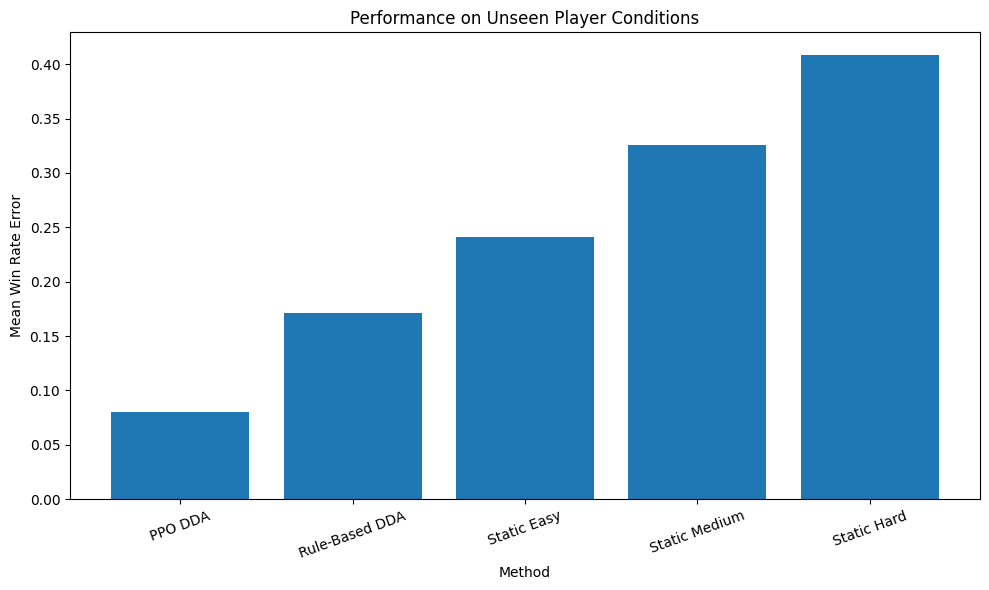

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [81]:
import matplotlib.pyplot as plt

plot_order = [
    "PPO DDA",
    "Rule-Based DDA",
    "Static Easy",
    "Static Medium",
    "Static Hard"
]

plot_data = (
    generalization_results_df
    .groupby("Method")["Win Rate Error"]
    .mean()
    .reindex(plot_order)
)

plt.figure(figsize=(10, 6))

plt.bar(
    plot_data.index,
    plot_data.values
)

plt.ylabel("Mean Win Rate Error")
plt.xlabel("Method")

plt.title(
    "Performance on Unseen Player Conditions"
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "results/generalization/figures/"
    "generalization_win_rate_error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ***Per Profile Generalization***

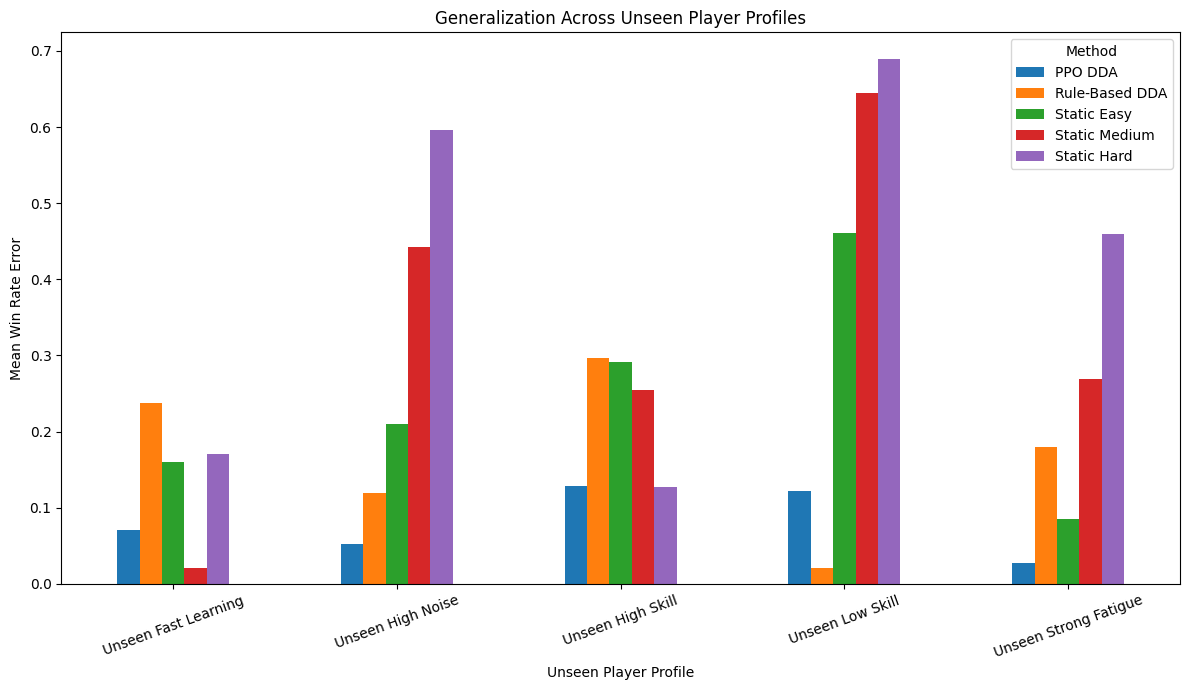

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [82]:
profile_plot = (
    generalization_results_df
    .groupby(
        [
            "Player Profile",
            "Method"
        ]
    )["Win Rate Error"]
    .mean()
    .unstack()
)

profile_plot = profile_plot[
    [
        "PPO DDA",
        "Rule-Based DDA",
        "Static Easy",
        "Static Medium",
        "Static Hard"
    ]
]

profile_plot.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.ylabel("Mean Win Rate Error")
plt.xlabel("Unseen Player Profile")

plt.title(
    "Generalization Across Unseen Player Profiles"
)

plt.xticks(rotation=20)

plt.legend(
    title="Method"
)

plt.tight_layout()

plt.savefig(
    "results/generalization/figures/"
    "per_profile_generalization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ***PPO vs Rule-Based across profiles***

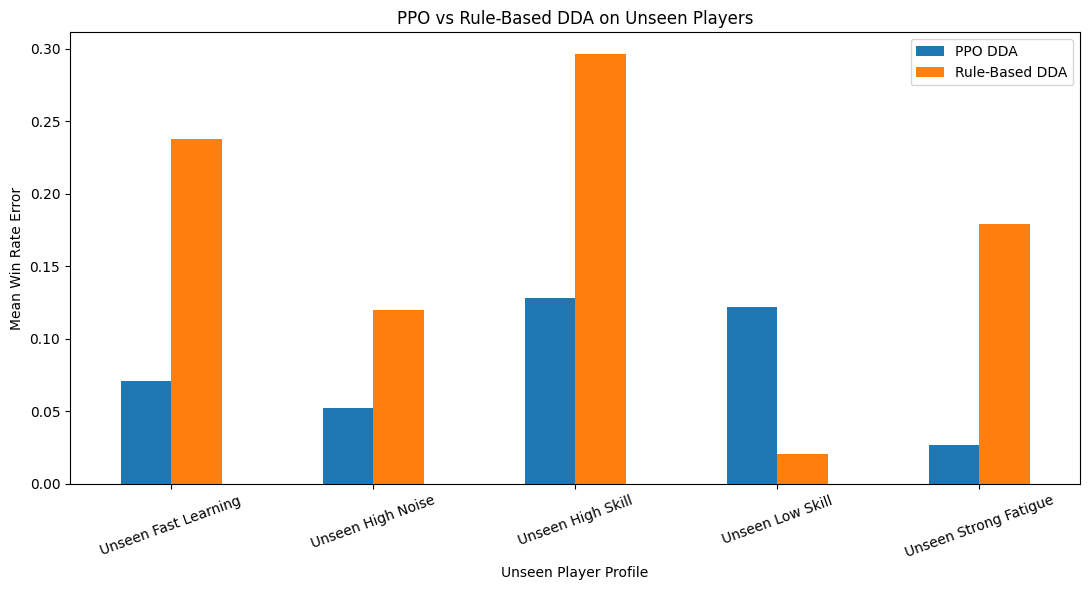

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [83]:
comparison = (
    profile_plot[
        [
            "PPO DDA",
            "Rule-Based DDA"
        ]
    ]
)

comparison.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylabel("Mean Win Rate Error")
plt.xlabel("Unseen Player Profile")

plt.title(
    "PPO vs Rule-Based DDA on Unseen Players"
)

plt.xticks(rotation=20)

plt.legend()

plt.tight_layout()

plt.savefig(
    "results/generalization/figures/"
    "ppo_vs_rule_generalization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ***Save Final Profile Table***

In [84]:
profile_error_pivot.round(6).to_csv(
    "results/generalization/tables/"
    "generalization_profile_results.csv"
)

profile_improvement_df.round(6).to_csv(
    "results/generalization/tables/"
    "generalization_profile_improvements.csv",
    index=False
)

generalization_summary.round(6).to_csv(
    "results/generalization/tables/"
    "generalization_summary.csv",
    index=False
)

print("All generalization tables saved successfully.")

All generalization tables saved successfully.


### ***Research Summary***

In [85]:
print("=" * 70)
print("GADDA-RL — GENERALIZATION EXPERIMENT")
print("=" * 70)

print(
    f"\nPPO Mean Win Rate Error: "
    f"{ppo_mean_error:.4f}"
)

rule_error = generalization_stats.loc[
    generalization_stats["Baseline"]
    == "Rule-Based DDA",
    "Baseline Mean Error"
].iloc[0]

rule_improvement = generalization_stats.loc[
    generalization_stats["Baseline"]
    == "Rule-Based DDA",
    "Improvement (%)"
].iloc[0]

rule_p = generalization_stats.loc[
    generalization_stats["Baseline"]
    == "Rule-Based DDA",
    "p-value"
].iloc[0]

rule_d = generalization_stats.loc[
    generalization_stats["Baseline"]
    == "Rule-Based DDA",
    "Cohen's d"
].iloc[0]

print(
    f"Rule-Based Mean Win Rate Error: "
    f"{rule_error:.4f}"
)

print(
    f"\nPPO improvement vs Rule-Based: "
    f"{rule_improvement:.2f}%"
)

print(
    f"P-value: {rule_p:.4e}"
)

print(
    f"Cohen's d: {rule_d:.4f}"
)

print(
    "\nUnseen profiles evaluated:",
    len(UNSEEN_PLAYER_PROFILES)
)

print(
    "Seeds per profile:",
    len(GENERALIZATION_SEEDS)
)

print(
    "Total evaluation episodes:",
    len(generalization_results_df)
)

print("\n" + "=" * 70)
print("GENERALIZATION EXPERIMENT COMPLETE")
print("=" * 70)

GADDA-RL — GENERALIZATION EXPERIMENT

PPO Mean Win Rate Error: 0.0800
Rule-Based Mean Win Rate Error: 0.1708

PPO improvement vs Rule-Based: 53.16%
P-value: 2.4506e-07
Cohen's d: 0.8467

Unseen profiles evaluated: 5
Seeds per profile: 10
Total evaluation episodes: 250

GENERALIZATION EXPERIMENT COMPLETE
